In [103]:
import pandas as pd
import os
from io import StringIO
from pandas import json_normalize
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import hmean

In [104]:
architecture = "GCN"
folder = os.path.join("output","test")

files = [f for f in os.listdir(folder) if architecture in f]
files

['Cora_GCN_50.json',
 'Cora_GCN_99.json',
 'Cora_GCN_20.json',
 'Cora_GCN_100.json']

In [105]:
column_list = ['unlearner', 'dataset', 'architecture', 'percentage', 
       'RunTime', 'PeakRSS_MB', 'CudaPeak_MB', 'AUS', 'UMIA',
       'sklearn.metrics.accuracy_score.test.unlearned.on_graph:True', 'sklearn.metrics.accuracy_score.forget.unlearned.on_graph:True',
       'sklearn.metrics.accuracy_score.train.unlearned.on_graph:True',
       'sklearn.metrics.accuracy_score.test.unlearned.on_graph:False',
       'sklearn.metrics.accuracy_score.test.original.on_graph:False',
       'f1_macro.test.unlearned.on_graph:True',
       'f1_macro.test.original.on_graph:True',
       'f1_macro.forget.unlearned.on_graph:True',
       'f1_macro.forget.original.on_graph:True',
       'Link Stealing Attack unlearned 0 exist/non_exist',
       'Link Stealing Attack 0 unlearned forget/non_exist', 'LinkTeller unlearn with sampler bfs+:',
       'LinkTeller original with sampler bfs+:']


In [106]:
total_df = pd.DataFrame()

for file in files:
    architecture = file.split("_")[1]
    if architecture == "SGC" and "CGU" in file:
        architecture = "SGC_CGU"
    
    if '50' in file:
        percentage = 50
    elif '99' in file:
        percentage = 99
    elif '100' in file:
        percentage = 100
    else:
        percentage = 20
        
    file = os.path.join(folder,file)
    with open(file, "r") as f:
        text = f.read().strip()

    if not text.startswith("["):
        text = "[" + text
    if text.endswith(","):
        text = text[:-1]
    if not text.endswith("]"):
        text = text + "]"

    df = pd.read_json(StringIO(text))

    df_expanded = json_normalize(df['parameters'])
    df = pd.concat([df.drop(columns='parameters'), df_expanded], axis=1)

    df['architecture'] = architecture
    df['percentage'] = percentage

    cols = list(df.columns)

    #cols.insert(2, cols.pop(cols.index('optimizer.parameters.lr')))

    cols.insert(2, cols.pop(cols.index('architecture')))

    df = df[cols]
    
    total_df = pd.concat([total_df,df])

In [107]:
total_df = total_df[column_list]

In [108]:
linkteller_unlearn = total_df["LinkTeller unlearn with sampler bfs+:"].apply(pd.Series)
linkteller_unlearn = linkteller_unlearn.rename(columns=lambda x: f"LinkTeller_unlearn_{x}")

linkteller_original = total_df["LinkTeller original with sampler bfs+:"].apply(pd.Series)
linkteller_original = linkteller_original.rename(columns=lambda x: f"LinkTeller_original_{x}")

total_df = pd.concat([total_df.drop(columns=[
    "LinkTeller unlearn with sampler bfs+:",
    "LinkTeller original with sampler bfs+:"
]), linkteller_unlearn, linkteller_original], axis=1)

In [109]:
total_df['percentage']

0     50
1     50
0     99
1     99
0     20
1     20
0    100
1    100
Name: percentage, dtype: int64

In [110]:
column_list = ['unlearner', 'dataset', 'architecture', 'percentage', 
       'RunTime', 'AUS', 'UMIA',
       'sklearn.metrics.accuracy_score.test.unlearned.on_graph:True', 'sklearn.metrics.accuracy_score.forget.unlearned.on_graph:True',
       'sklearn.metrics.accuracy_score.train.unlearned.on_graph:True',
       'sklearn.metrics.accuracy_score.test.unlearned.on_graph:False',
       'sklearn.metrics.accuracy_score.test.original.on_graph:False',
       'Link Stealing Attack unlearned 0 exist/non_exist',
       'Link Stealing Attack 0 unlearned forget/non_exist', 'LinkTeller_unlearn_auc',
       'LinkTeller_unlearn_ap', 'LinkTeller_original_auc', 'LinkTeller_original_ap']

total_df = total_df[column_list]
total_df.reset_index(drop=True, inplace=True)

In [111]:
metric_cols = [c for c in column_list if c not in ["unlearner","dataset","architecture","lr","RunTime", 'optimizer.parameters.lr',  'Link Stealing Attack unlearned 0 exist/non_exist',
 'Link Stealing Attack 0 unlearned forget/non_exist',
 'LinkTeller_unlearn_auc',
 'LinkTeller_unlearn_ap',
 'LinkTeller_original_auc',
 'LinkTeller_original_ap']]

In [112]:
total_df

,unlearner,dataset,architecture,percentage,RunTime,AUS,UMIA,sklearn.metrics.accuracy_score.test.unlearned.on_graph:True,sklearn.metrics.accuracy_score.forget.unlearned.on_graph:True,sklearn.metrics.accuracy_score.train.unlearned.on_graph:True,sklearn.metrics.accuracy_score.test.unlearned.on_graph:False,sklearn.metrics.accuracy_score.test.original.on_graph:False,Link Stealing Attack unlearned 0 exist/non_exist,Link Stealing Attack 0 unlearned forget/non_exist,LinkTeller_unlearn_auc,LinkTeller_unlearn_ap,LinkTeller_original_auc,LinkTeller_original_ap
0,Identity,Cora,GCN,50,0.000326,0.969323,0.528630,0.865314,0.882114,0.892821,0.881919,0.881919,0.922460,0.919095,0.560499,0.849171,0.564857,0.850040
1,GoldModelGraph,Cora,GCN,50,1.379400,0.954627,0.512270,0.869004,0.906504,0.922564,0.869004,0.881919,0.920618,0.917376,0.565017,0.850599,0.561361,0.849551
2,Identity,Cora,GCN,99,0.000393,0.971388,0.528630,0.815498,0.869549,0.890256,0.881919,0.881919,0.922461,0.919574,0.500069,0.853838,0.500485,0.853842
3,GoldModelGraph,Cora,GCN,99,1.343694,0.953460,0.787879,0.760148,0.910200,0.965128,0.760148,0.881919,0.919850,0.917559,0.500353,0.853855,0.500987,0.853862
4,Identity,Cora,GCN,20,0.000392,0.974427,0.528630,0.881919,0.894299,0.911795,0.881919,0.881919,0.922460,0.918388,0.721019,0.868663,0.720061,0.868362
5,GoldModelGraph,Cora,GCN,20,1.353776,0.978888,0.517382,0.883764,0.910314,0.925128,0.883764,0.881919,0.921174,0.916848,0.721627,0.869577,0.720185,0.868464
6,Identity,Cora,GCN,100,0.000363,0.971388,0.528630,0.815498,0.870384,0.891282,0.881919,0.881919,0.922461,0.920111,0.500000,0.853976,0.500000,0.853976
7,GoldModelGraph,Cora,GCN,100,1.351550,0.956600,NaN,0.760148,0.909897,0.965641,0.760148,0.881919,0.919586,0.917714,0.500000,0.853976,0.500000,0.853976


In [113]:
df_to_plot = total_df[['unlearner','dataset','percentage','UMIA','sklearn.metrics.accuracy_score.test.unlearned.on_graph:False']]
df_to_plot['percentage'] = pd.Categorical(df_to_plot['percentage'], categories=[20, 50, 99, 100], ordered=True)
df_to_plot["UMIA"].fillna(0.5, inplace=True)
df_to_plot

/tmp/ipykernel_1127083/627288959.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_to_plot['percentage'] = pd.Categorical(df_to_plot['percentage'], categories=[20, 50, 99, 100], ordered=True)
/tmp/ipykernel_1127083/627288959.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_to_

,unlearner,dataset,percentage,UMIA,sklearn.metrics.accuracy_score.test.unlearned.on_graph:False
0,Identity,Cora,50,0.528630,0.881919
1,GoldModelGraph,Cora,50,0.512270,0.869004
2,Identity,Cora,99,0.528630,0.881919
3,GoldModelGraph,Cora,99,0.787879,0.760148
4,Identity,Cora,20,0.528630,0.881919
5,GoldModelGraph,Cora,20,0.517382,0.883764
6,Identity,Cora,100,0.528630,0.881919
7,GoldModelGraph,Cora,100,0.500000,0.760148


In [114]:
df_to_plot.loc[df_to_plot.unlearner=='GoldModelGraph']

,unlearner,dataset,percentage,UMIA,sklearn.metrics.accuracy_score.test.unlearned.on_graph:False
1,GoldModelGraph,Cora,50,0.512270,0.869004
3,GoldModelGraph,Cora,99,0.787879,0.760148
5,GoldModelGraph,Cora,20,0.517382,0.883764
7,GoldModelGraph,Cora,100,0.500000,0.760148


/tmp/ipykernel_1127083/327034765.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_to_plot["percentage"] = df_to_plot["percentage"].astype(pct_dtype)
/tmp/ipykernel_1127083/327034765.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_to_plot


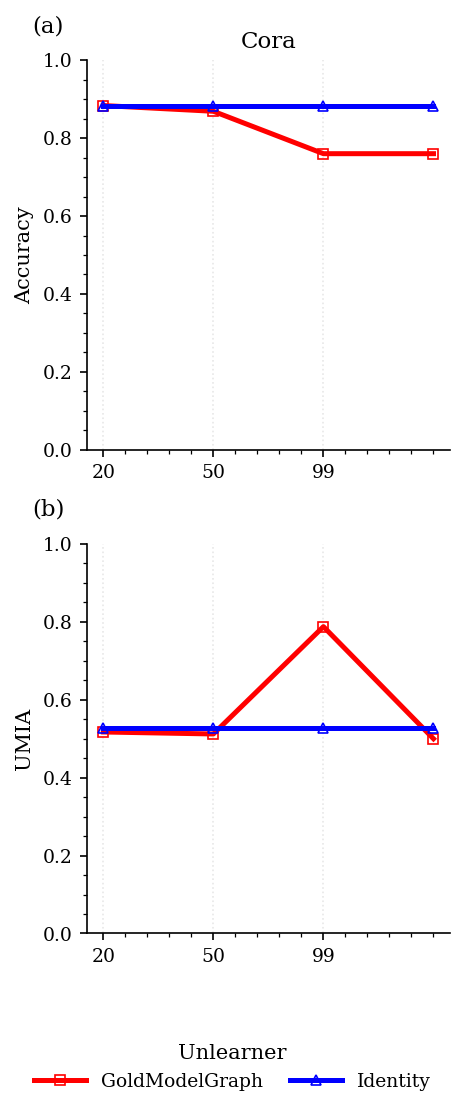

In [115]:
import pandas as pd
import matplotlib.pyplot as plt
from string import ascii_lowercase

# ---------- Global style (paper-ish) ----------
plt.rcParams.update({
    "font.family": "serif",           # looks academic
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.8,
    "figure.dpi": 150,                # on-screen
    "savefig.dpi": 300,               # export
})

ACC = "sklearn.metrics.accuracy_score.test.unlearned.on_graph:False"
UMIA = "UMIA"

# Ensure ordered categorical for percentages
pct_dtype = pd.api.types.CategoricalDtype(categories=[20, 50, 99,100], ordered=True)
df_to_plot["percentage"] = df_to_plot["percentage"].astype(pct_dtype)

# Aggregate duplicates (mean) for BOTH metrics
agg = (
    df_to_plot
    .groupby(["dataset", "unlearner", "percentage"], as_index=False)[[ACC, UMIA]]
    .mean()
)

datasets = agg["dataset"].unique()

# 2 rows: row 0 = Accuracy, row 1 = UMIA
fig, axes = plt.subplots(
    2, len(datasets),
    figsize=(3.2*len(datasets), 6.6),
    sharey=True, squeeze=False
)

# ----- Color/marker palette (same as before) -----
all_unlearners = agg["unlearner"].unique().tolist()
highlight_names = ["GoldModelGraph", "Identity"]

base_cmap = plt.get_cmap("tab20")
others = [u for u in all_unlearners if u not in highlight_names]
other_colors = {u: base_cmap(i % base_cmap.N) for i, u in enumerate(others)}

color_map = {**other_colors, "GoldModelGraph": "red", "Identity": "blue"}

marker_map = {"GoldModelGraph": "s", "Identity": "^"}
default_markers = ["o", "D", "v", "P", "X", "*", "h", ">", "<"]
for i, u in enumerate(others):
    marker_map.setdefault(u, default_markers[i % len(default_markers)])

style_map = {
    "GoldModelGraph": {"linewidth": 2.4, "zorder": 5},
    "Identity": {"linewidth": 2.4, "zorder": 5},
}

def plot_row(ax_row, metric, ylabel=None, panel_offset=0):
    """Plot one metric across all dataset columns on the given axes row."""
    handles, labels = [], []
    for j, dataset in enumerate(datasets):
        ax = ax_row[j]
        sdf = agg[agg["dataset"] == dataset]

        for unlearner, udf in sdf.groupby("unlearner"):
            udf = udf.sort_values("percentage", key=lambda s: s.cat.codes)
            x = udf["percentage"].cat.codes
            kwargs = {
                "color": color_map[unlearner],
                "linewidth": 1.6,
                "marker": marker_map[unlearner],
                "markersize": 5,
                "markeredgewidth": 0.8,
                "markerfacecolor": "none",
                "zorder": 2,
            }
            kwargs.update(style_map.get(unlearner, {}))

            (line,) = ax.plot(x, udf[metric], label=unlearner, **kwargs)
            if unlearner not in labels:
                handles.append(line); labels.append(unlearner)

        # Cosmetics (titles only on top row; x labels/ticks on both)
        if ax is axes[0, j]:
            ax.set_title(dataset)
        if ylabel and j == 0:
            ax.set_ylabel(ylabel)

        ax.set_xticks([0, 1, 2])
        ax.set_xticklabels([20, 50, 99])
        ax.set_ylim(0, 1)
        ax.minorticks_on()
        ax.grid(axis="x", linestyle=":", alpha=0.3)

        # Panel labels (a), (b), (c), ... continuing across rows
        label_idx = panel_offset + j
        ax.text(-0.15, 1.06, f"({ascii_lowercase[label_idx]})",
                transform=ax.transAxes, va="bottom", ha="left", fontsize=11)
    return handles, labels

# Top row: Accuracy (identical look)
top_handles, top_labels = plot_row(axes[0], ACC, ylabel="Accuracy", panel_offset=0)

# Bottom row: UMIA
_ , _ = plot_row(axes[1], UMIA, ylabel="UMIA", panel_offset=len(datasets))

# ----- Single legend below; wide & low -----
ncols = min(len(top_labels), 12)
fig.legend(
    top_handles, top_labels,
    loc="lower center",
    ncol=ncols,
    bbox_to_anchor=(0.5, -0.12),
    frameon=False,
    title="Unlearner",
    fontsize=9,
    handlelength=2.8,
    columnspacing=1.4,
    markerscale=1.0,
)

# Space for legend + neat layout
plt.subplots_adjust(bottom=0.20, wspace=0.25, hspace=0.35)
plt.tight_layout()

# Save (vector-friendly)
fig.savefig(os.path.join("figures", "unlearning_accuracy_and_umia.pdf"), bbox_inches="tight", transparent=True)
plt.show()
